# 02 — Modell-Ebene-Vergleich der drei Loss-Optionen

Konsolidiert die Metriken aus `results/model_metrics_squared_error.json`,
`results/model_metrics_poisson_log.json` und `results/model_metrics_poisson_native.json`
und beantwortet die zentrale Frage **auf reiner Modell-Ebene**:

> Welche Loss-Option liefert für EBM und XGBoost die beste Performance auf der
> rechtsschiefen `cnt`-Verteilung?

**Wichtige methodische Vorbemerkung:** Auf Modell-Ebene sind Option 2 (Beiträge auf
Log-Skala) und Option 3 (Beiträge approximativ in Ausleihen) **identisch** —
beide trainieren denselben Poisson-Loss und liefern dieselben Vorhersagen auf
der `cnt`-Skala. Der Unterschied entsteht erst in Notebook 03 bei der
Beitrags-Extraktion. Dieses Notebook macht das numerisch sichtbar.


In [1]:
from __future__ import annotations

import sys, json
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utils import RESULTS_DIR
from utils.models import LOSS_OPTIONS

# Alle drei Metriken-Dateien einlesen
results = {}
for key in LOSS_OPTIONS:
    path = RESULTS_DIR / f"model_metrics_{key}.json"
    if path.exists():
        results[key] = json.loads(path.read_text())
    else:
        print(f"WARNUNG: {path} fehlt — Notebook 02{'abc'[list(LOSS_OPTIONS).index(key)]} noch nicht gelaufen?")

print(f"Geladene Optionen: {list(results)}")


Geladene Optionen: ['squared_error', 'poisson_log', 'poisson_native']


## 1. Konsolidierte Metriken-Tabelle

Zeilen: Option × Modell. Spalten: alle Performance-Metriken auf cnt-Skala.


In [2]:
rows = []
for key, r in results.items():
    label = r["loss_option"]["label"]
    for model_name in ("xgb", "ebm"):
        m = r["metrics"][model_name]
        rows.append({
            "Option": label,
            "Modell": model_name.upper(),
            "RMSE": m["rmse"],
            "MAE": m["mae"],
            "R²": m["r2"],
            "Poisson-Dev.": m["poisson_deviance"],
            "min(pred)": m["min_prediction"],
            "neg. preds": m["n_negative_predictions"],
            "Trainingszeit (s)": r["training_time_seconds"][model_name],
        })

df = pd.DataFrame(rows)
display(df.round(4))


,Option,Modell,RMSE,MAE,R²,Poisson-Dev.,min(pred),neg. preds,Trainingszeit (s)
0,Option 1: Squared Error,XGB,39.1285,24.3074,0.9515,12.0329,-40.8499,108,1.9822
1,Option 1: Squared Error,EBM,55.3132,36.1908,0.9032,59.9873,-202.5589,358,13.7678
2,Option 2: Poisson-Deviance (Beitraege auf Log-...,XGB,39.0060,23.6827,0.9518,7.0615,1.9062,0,2.1952
3,Option 2: Poisson-Deviance (Beitraege auf Log-...,EBM,48.3689,26.9987,0.9259,9.7242,0.4465,0,12.7909
4,Option 3: Poisson-Deviance (Beitraege approxim...,XGB,39.0060,23.6827,0.9518,7.0615,1.9062,0,1.9403
5,Option 3: Poisson-Deviance (Beitraege approxim...,EBM,48.3689,26.9987,0.9259,9.7242,0.4465,0,13.1472


## 2. Direkter Vergleich Option 2 vs. Option 3 auf Modell-Ebene

Wenn Option 2 und 3 wirklich dasselbe Modell sind, müssen alle Metriken
**identisch bis auf numerisches Rauschen** sein. Falls nicht, läuft etwas falsch.


In [3]:
if "poisson_log" in results and "poisson_native" in results:
    cols = ["rmse", "mae", "r2", "poisson_deviance"]
    diffs = []
    for model_name in ("xgb", "ebm"):
        m2 = results["poisson_log"]["metrics"][model_name]
        m3 = results["poisson_native"]["metrics"][model_name]
        for c in cols:
            diffs.append({
                "Modell": model_name.upper(),
                "Metrik": c,
                "Option 2": m2[c],
                "Option 3": m3[c],
                "|Differenz|": abs(m2[c] - m3[c]),
            })
    diff_df = pd.DataFrame(diffs)
    display(diff_df.round(8))

    max_abs_diff = diff_df["|Differenz|"].max()
    print(f"\nMaximale absolute Differenz: {max_abs_diff:.2e}")
    if max_abs_diff < 1e-6:
        print("=> Option 2 und 3 sind auf Modell-Ebene IDENTISCH (wie methodisch erwartet).")
        print("   Die Entscheidung zwischen ihnen ist eine Erklaerungs-Schicht-Entscheidung,")
        print("   keine Modell-Ebene-Entscheidung.")
    else:
        print("=> Differenz groesser als erwartet — Hyperparameter / Random-Seeds pruefen!")
else:
    print("Eines der beiden Poisson-Notebooks fehlt — Vergleich uebersprungen.")


,Modell,Metrik,Option 2,Option 3,|Differenz|
0,XGB,rmse,39.006035,39.006035,0.0
1,XGB,mae,23.682694,23.682694,0.0
2,XGB,r2,0.951838,0.951838,0.0
3,XGB,poisson_deviance,7.061543,7.061543,0.0
4,EBM,rmse,48.368917,48.368917,0.0
5,EBM,mae,26.998733,26.998733,0.0
6,EBM,r2,0.925942,0.925942,0.0
7,EBM,poisson_deviance,9.724249,9.724249,0.0



Maximale absolute Differenz: 0.00e+00
=> Option 2 und 3 sind auf Modell-Ebene IDENTISCH (wie methodisch erwartet).
   Die Entscheidung zwischen ihnen ist eine Erklaerungs-Schicht-Entscheidung,
   keine Modell-Ebene-Entscheidung.


## 3. Visualisierung der Kern-Metriken


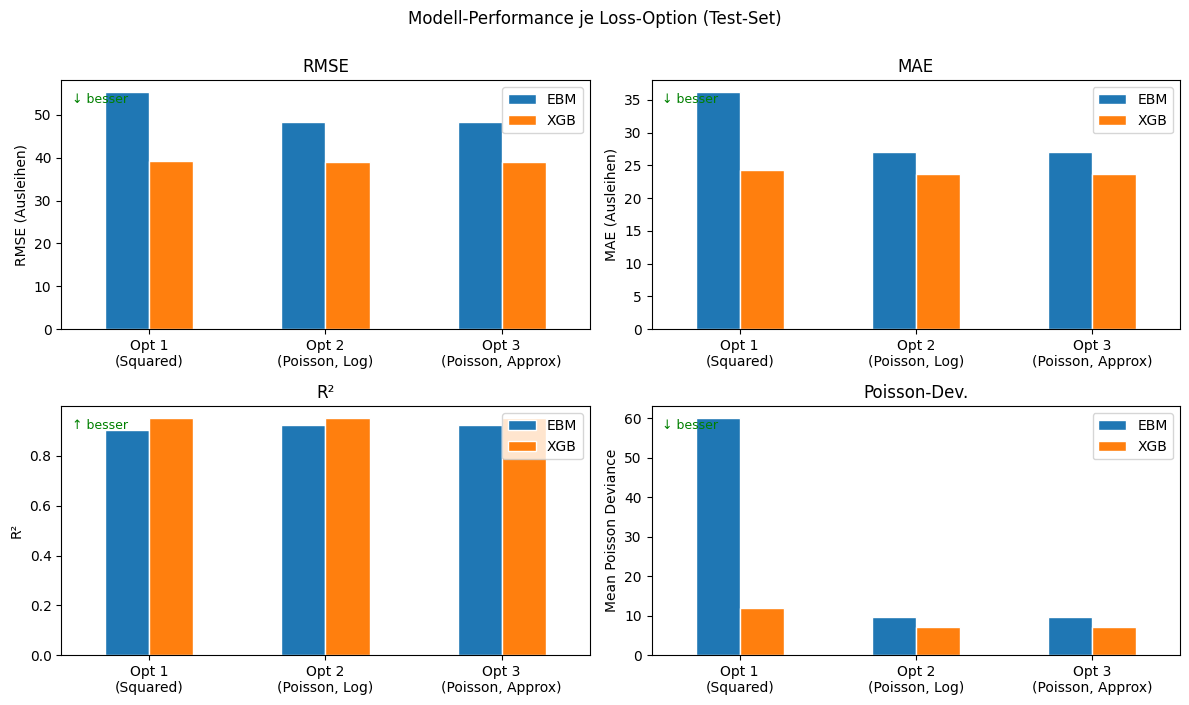

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
metrics_to_plot = [
    ("RMSE", "RMSE (Ausleihen)", False),
    ("MAE", "MAE (Ausleihen)", False),
    ("R²", "R²", True),
    ("Poisson-Dev.", "Mean Poisson Deviance", False),
]
short_labels = {
    "Option 1: Squared Error": "Opt 1\n(Squared)",
    "Option 2: Poisson-Deviance (Beitraege auf Log-Skala)": "Opt 2\n(Poisson, Log)",
    "Option 3: Poisson-Deviance (Beitraege approximativ auf Ausleihe-Skala)": "Opt 3\n(Poisson, Approx)",
}
df_plot = df.copy()
df_plot["Option_short"] = df_plot["Option"].map(short_labels)

for ax, (col, ylabel, higher_is_better) in zip(axes.flat, metrics_to_plot):
    pivot = df_plot.pivot(index="Option_short", columns="Modell", values=col)
    pivot.plot.bar(ax=ax, edgecolor="white")
    ax.set_title(col)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=0)
    ax.legend(title="")
    if higher_is_better:
        ax.text(0.02, 0.95, "↑ besser", transform=ax.transAxes,
                fontsize=9, color="green", va="top")
    else:
        ax.text(0.02, 0.95, "↓ besser", transform=ax.transAxes,
                fontsize=9, color="green", va="top")

plt.suptitle("Modell-Performance je Loss-Option (Test-Set)", y=1.00, fontsize=12)
plt.tight_layout()
plt.show()


## 4. Plausibilitäts-Check: Negative Vorhersagen

Squared-Error-Modelle können auf Count-Daten unsinnige negative Werte vorhersagen.
Poisson-Modelle (via Log-Link / `exp()`) sind strikt positiv. Das ist **kein**
RMSE-Argument, aber ein wichtiges Argument für die Plausibilität der späteren
Erklärungen — eine negative Ausleihe-Vorhersage ist domänenfremd, und ein LLM,
das eine solche Vorhersage erklären soll, wird mindestens irritiert sein.


In [5]:
neg_summary = df[["Option", "Modell", "min(pred)", "neg. preds"]].copy()
display(neg_summary)

any_neg = (neg_summary["neg. preds"] > 0).any()
if any_neg:
    print("\nNegative Vorhersagen aufgetreten — siehe Tabelle.")
    print("Argument gegen Option 1 (Squared Error) auf Plausibilitaets-Achse,")
    print("auch wenn RMSE/MAE konkurrenzfaehig sind.")
else:
    print("\nKeine negativen Vorhersagen — auf diesem Datensatz/Run kein Plausibilitaets-Problem.")


,Option,Modell,min(pred),neg. preds
0,Option 1: Squared Error,XGB,-40.849911,108
1,Option 1: Squared Error,EBM,-202.558872,358
2,Option 2: Poisson-Deviance (Beitraege auf Log-...,XGB,1.906240,0
3,Option 2: Poisson-Deviance (Beitraege auf Log-...,EBM,0.446458,0
4,Option 3: Poisson-Deviance (Beitraege approxim...,XGB,1.906240,0
5,Option 3: Poisson-Deviance (Beitraege approxim...,EBM,0.446458,0



Negative Vorhersagen aufgetreten — siehe Tabelle.
Argument gegen Option 1 (Squared Error) auf Plausibilitaets-Achse,
auch wenn RMSE/MAE konkurrenzfaehig sind.


## 5. Zusammenfassung & Empfehlung

Die Empfehlung ist explizit **modell-ebene-only**. Die Wahl zwischen Option 2
und 3 ist hier nicht entscheidbar — sie wird in Notebook 03 (Erklärungs-Generierung)
und der nachgelagerten LLM-Evaluation (Notebook 07) beantwortet.


In [6]:
print("=" * 70)
print("ZUSAMMENFASSUNG MODELL-EBENE")
print("=" * 70)

# Beste Option je Modell und Metrik
for model_name in ("XGB", "EBM"):
    sub = df[df["Modell"] == model_name]
    print(f"\n{model_name}:")
    print(f"  beste RMSE:           {sub.loc[sub['RMSE'].idxmin(), 'Option']}")
    print(f"  beste MAE:            {sub.loc[sub['MAE'].idxmin(), 'Option']}")
    print(f"  bestes R²:            {sub.loc[sub['R²'].idxmax(), 'Option']}")
    print(f"  beste Poisson-Dev.:   {sub.loc[sub['Poisson-Dev.'].idxmin(), 'Option']}")

print("\n" + "-" * 70)
print("METHODISCHE BEMERKUNGEN")
print("-" * 70)
print("- Option 2 und 3 sind auf Modell-Ebene identisch.")
print("  Der Unterschied entsteht erst in Notebook 03 (Beitrags-Extraktion).")
print("- Option 1 kann negative Vorhersagen produzieren -> Plausibilitaets-Risiko")
print("  fuer die LLM-Erklaerungen.")
print("- Final-Entscheidung sollte zusaetzlich zur Modell-Performance die")
print("  Erklaerungs-Faithfulness (Notebook 07) beruecksichtigen.")


ZUSAMMENFASSUNG MODELL-EBENE

XGB:
  beste RMSE:           Option 2: Poisson-Deviance (Beitraege auf Log-Skala)
  beste MAE:            Option 2: Poisson-Deviance (Beitraege auf Log-Skala)
  bestes R²:            Option 2: Poisson-Deviance (Beitraege auf Log-Skala)
  beste Poisson-Dev.:   Option 2: Poisson-Deviance (Beitraege auf Log-Skala)

EBM:
  beste RMSE:           Option 2: Poisson-Deviance (Beitraege auf Log-Skala)
  beste MAE:            Option 2: Poisson-Deviance (Beitraege auf Log-Skala)
  bestes R²:            Option 2: Poisson-Deviance (Beitraege auf Log-Skala)
  beste Poisson-Dev.:   Option 2: Poisson-Deviance (Beitraege auf Log-Skala)

----------------------------------------------------------------------
METHODISCHE BEMERKUNGEN
----------------------------------------------------------------------
- Option 2 und 3 sind auf Modell-Ebene identisch.
  Der Unterschied entsteht erst in Notebook 03 (Beitrags-Extraktion).
- Option 1 kann negative Vorhersagen produzieren -> Plau

## 6. Output: konsolidierte Tabelle für Belegarbeit


In [7]:
out_csv = RESULTS_DIR / "model_comparison_summary.csv"
df.to_csv(out_csv, index=False)
print(f"Konsolidierte Tabelle gespeichert: {out_csv}")


Konsolidierte Tabelle gespeichert: /Users/anton/Desktop/SoSe26/Belegarbeit/Implementation_1205/results/model_comparison_summary.csv
